# FILTROS

In [ ]:
# =============================================================
# IMPORTS GLOBALES DEL NOTEBOOK (version Google Colab)
# Todas las dependencias se cargan en esta unica celda inicial.
# =============================================================

# Estandar
import os
import io
import json
import shutil

# Utilidades de Google Colab
from google.colab import userdata
from google.colab import files as colab_files

# Procesamiento de imagenes y numerico
import cv2
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Aprendizaje profundo
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

# Utilidades de ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Caracteristicas clasicas (HOG)
from skimage.feature import hog

# Interfaz interactiva en el notebook
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image as PILImage

# Roboflow (descarga del dataset)
from roboflow import Roboflow


**Filtro de media:** El filtro de media es un filtro lineal de suavizado que reemplaza el valor de cada píxel por el promedio de los valores dentro de una vecindad local. Es uno de los filtros más simples para reducción de ruido.
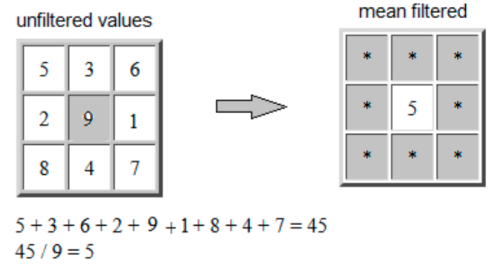

Ejemplo:

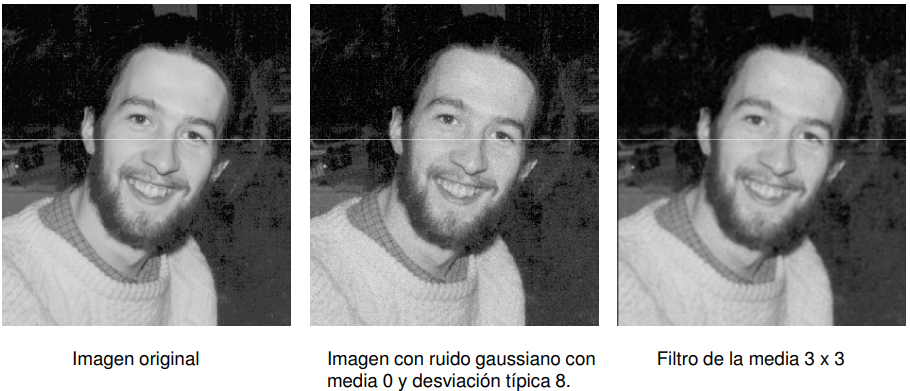


Ventajas:
- Fácil implementación
- Reduce ruido gaussiano
- Bajo costo computacional

Desventajas:
- El filtro de la media es bastante sensible a cambios locales.
- Puede crear nuevas intensidades de grises que no aparecían en la imagen.
- Borra bordes
- Introduce desenfoque
- No distingue ruido de señal

In [ ]:
# Filtro de media
img = cv2.imread('imagen.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mean = cv2.blur(img, (5,5))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)

plt.subplot(1,2,2)
plt.title("Filtro de Media")
plt.imshow(mean)

plt.show()

**Filtro mediana:** Filtro no lineal de procesamiento de imágenes y señales que reduce el ruido reemplazando cada valor por la mediana de sus vecinos.

Se visita cada píxel de la imagen y se reemplaza
por la mediana de los píxeles vecinos. La mediana se calcula ordenando los valores de los pixeles vecinos en orden y seleccionado el que queda en medio.

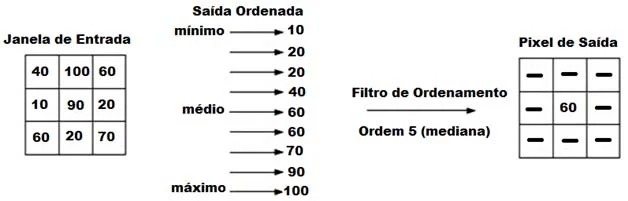

Ejemplo:

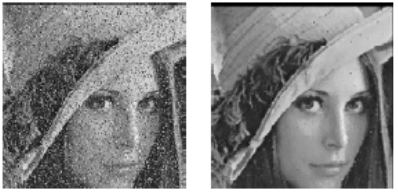


Ventaja:
- Tiene la ventaja de que el valor final del pixel es un valor real presente en la imagen y no un promedio, de este modo se reduce el efecto borroso que tienen las imagenes que han sufrido un filtro de media.
- Da muy buenos resultados en caso de ruido sal y pimienta, ya que es menos sensible a valores extremos.

Desventaja:
- Resulta más complejo de calcular ya que hay que ordenar los
diferentes valores que aparecen en los pixeles incluidos en la ventana y determinar cual es el valor
central

In [ ]:
# Filtro de mediana con ruido sal y pimienta
img = cv2.imread('imagen.jpg', 0)

def salt_pepper_noise(image, prob):
    noisy = image.copy()
    rows, cols = image.shape

    for i in range(rows):
        for j in range(cols):
            r = np.random.rand()
            if r < prob:
                noisy[i,j] = 0        # pimienta
            elif r > 1 - prob:
                noisy[i,j] = 255      # sal

    return noisy

noisy = salt_pepper_noise(img, 0.2)

median = cv2.medianBlur(noisy, 5)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,3,2)
plt.title("Ruido Sal y Pimienta")
plt.imshow(noisy, cmap='gray')

plt.subplot(1,3,3)
plt.title("Filtro Mediana")
plt.imshow(median, cmap='gray')

plt.show()

**Filtro logarítmico:** es una transformación puntual no lineal utilizada en procesamiento digital de imágenes para mejorar el contraste, especialmente en regiones oscuras. A diferencia de los filtros espaciales (media, gaussiano), este opera sobre cada píxel de forma independiente, sin considerar vecinos.

Formula: ***s=clog(1+r)***

Donde:

- r: intensidad del píxel de entrada
- s: intensidad del píxel de salida
- c: constante de escala
- log: logaritmo (generalmente base 10 o natural)

Ejemplo:

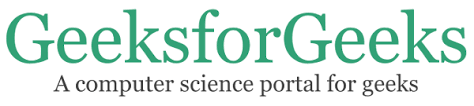

Salida:

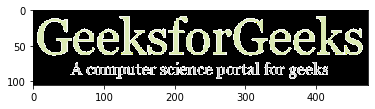

Ventajas:
- Mejora contraste en zonas oscuras
- Útil para imágenes con alto rango dinámico
- Realza detalles ocultos

Desventajas:
- Reduce contraste en zonas brillantes
- No elimina ruido
- Requiere postprocesamiento (normalización)

In [ ]:
# Filtro logaritmico
# Leer imagen en escala de grises
img = cv2.imread('imagen.jpg', 0)

# Convertir a float para evitar saturacion
img_float = np.float32(img)

# Aplicar transformacion logaritmica
log_img = np.log(1 + img_float)

# Normalizar a rango [0,255]
log_img = cv2.normalize(log_img, None, 0, 255, cv2.NORM_MINMAX)

# Convertir a uint8
log_img = np.uint8(log_img)

# Mostrar resultados
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Filtro Logaritmico")
plt.imshow(log_img, cmap='gray')

plt.show()

**Filtro de cuadro normalizado:** es un filtro lineal de suavizado que aplica una convolución con un kernel uniforme cuyos coeficientes suman 1. Es una forma formal del filtro de media, pero expresado como operación de convolución.

Se usa para: Suavizar imágenes, reducir ruido y eliminar pequeñas variaciones de intensidad.

Modelo matemático: La operación se define como una convolución: g(x,y)=f(x,y)∗h(x,y) donde h(x,y) es el kernel

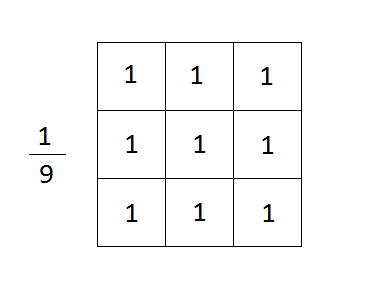


Ejemplo:

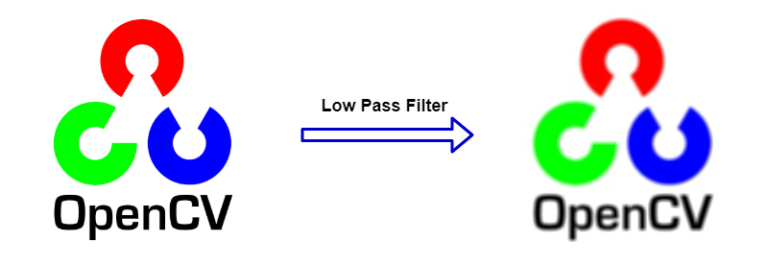

Ventajas:
- Muy simple de implementar
- Bajo costo computacional
- Mantiene el brillo global
- Ideal para suavizado básico

Desventajas:
- Difumina bordes
- No distingue ruido de señal
- Menos eficiente que el filtro gaussiano
- Introduce efecto de “borrosidad uniforme”

In [ ]:
# Filtro cuadro normalizado (box filter)
img = cv2.imread('imagen.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

kernel = np.ones((3,3), np.float32) / 9
box = cv2.filter2D(img, -1, kernel)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)

plt.subplot(1,2,2)
plt.title("Filtro Cuadro Normalizado")
plt.imshow(box)

plt.show()

**Filtro gaussiano:** Es un filtro lineal de suavizado que utiliza una función gaussiana (distribución normal) para ponderar los píxeles vecinos. A diferencia del filtro de media, no todos los píxeles pesan igual, los píxeles cercanos al centro tienen mayor influencia.

Se usa para: Reducir ruido, suavizar imágenes y preprocesamiento antes de detectar bordes.

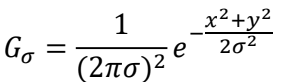


Ejemplo:

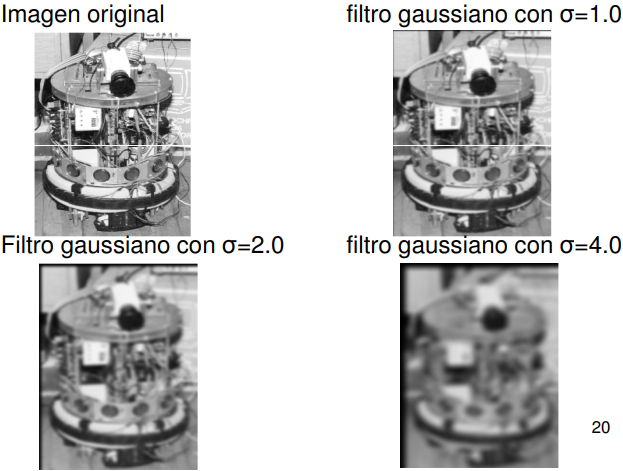


Ventajas:
- Suaviza sin perder tanto detalle, ya que al dar más peso al centro, el desenfoque se ve más orgánico que en un filtro de media.
- Reduce ruido gaussiano eficientemente.
- Es el paso previo ideal para algoritmos de detección de bordes.
- El parámetro Sigma (\(\sigma \)) permite ajustar exactamente cuánto detalle se desea eliminar.

Desventajas:
- Suaviza los bordes de los objetos, lo que puede dificultar la segmentación precisa (difumina bordes)
- Ineficacia contra ruido "Sal y Pimienta"
- Costo computacional, los kernels grandes consumen más recursos que filtros más simples.
- Distorsión de esquinas, puede redondear esquinas y detalles finos de la estructura de la imagen.

In [ ]:
# Filtro gaussiano con distintos sigma
img = cv2.imread('imagen.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gauss_05 = cv2.GaussianBlur(img, (7,7), 0.5)
gauss_1  = cv2.GaussianBlur(img, (7,7), 1)
gauss_2  = cv2.GaussianBlur(img, (7,7), 2)
gauss_5  = cv2.GaussianBlur(img, (7,7), 5)
gauss_30  = cv2.GaussianBlur(img, (7,7), 30)

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(2,3,2)
plt.title("sigma = 0.5")
plt.imshow(gauss_05)
plt.axis("off")

plt.subplot(2,3,3)
plt.title("sigma = 1")
plt.imshow(gauss_1)
plt.axis("off")

plt.subplot(2,3,4)
plt.title("sigma = 2")
plt.imshow(gauss_2)
plt.axis("off")

plt.subplot(2,3,5)
plt.title("sigma = 5")
plt.imshow(gauss_5)
plt.axis("off")

plt.subplot(2,3,6)
plt.title("sigma = 30")
plt.imshow(gauss_30)
plt.axis("off")

plt.tight_layout()
plt.show()

**Filtro Laplace:** Un filtro laplaciano es un detector de bordes que se utiliza para calcular las segundas derivadas de una imagen, midiendo la velocidad a la que cambian las primeras derivadas. Esto permite determinar si un cambio en los valores de píxeles adyacentes se debe a un borde o a una progresión continua.


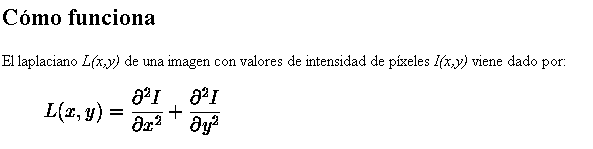

Los núcleos de filtro laplaciano suelen contener valores negativos dispuestos en forma de cruz, centrados en la matriz. Los vértices pueden ser cero o positivos. El valor central puede ser negativo o positivo. La siguiente matriz es un ejemplo de un núcleo de 3x3 para un filtro laplaciano.

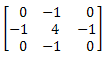


Ejemplo:

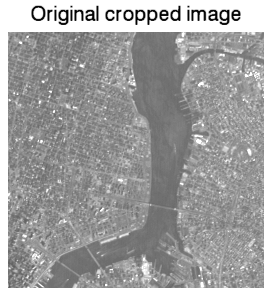
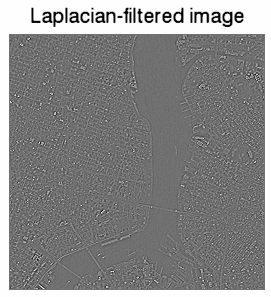

Ventajas:
- Localiza bordes en cualquier dirección.
- Su implementación matemática es sencilla y requiere poco poder de cómputo.
- Es excelente para resaltar líneas finas y puntos aislados.

Desventajas:
- Es sensibilidad al ruido, por lo que cualquier grano o imperfección en la imagen se interpreta como un borde.
- Al ser una segunda derivada, genera dos respuestas (una positiva y una negativa) por cada borde.
- A diferencia de los filtros de Sobel o Prewitt, no te dice si el borde es horizontal o vertical.
- Los resultados pueden ser inconsistentes en zonas con gradientes de intensidad suaves.

In [ ]:
# Filtro laplaciano
img = cv2.imread('imagen.jpg', 0)

lap = cv2.Laplacian(img, cv2.CV_64F)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Filtro Laplaciano")
plt.imshow(lap, cmap='gray')

plt.show()

**Filtro Sobel:** El filtro Sobel es un operador de gradiente (derivada de primer orden) utilizado para: detectar bordes, calcular cambios de intensidad y determinar la dirección del borde. A diferencia del Laplaciano, Sobel sí detecta dirección (horizontal y vertical).

Nucleos de convolución 3x3 Sobel
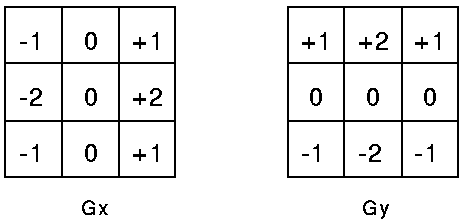

Magnitud
image.png

Ejemplo:

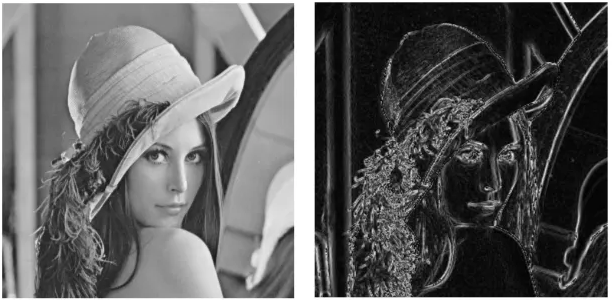

Ventajas:
- Es muy rápido de procesar debido a que utiliza núcleos pequeños de 3x3.- Su implementación matemática es sencilla y fácil de entender.
- Al promediar los píxeles vecinos, reduce ligeramente el ruido visual.
- Permite separar los bordes horizontales de los verticales, lo que ayuda a analizar la orientación de las formas.

Desventajas:
- Aunque suaviza un poco, sigue siendo vulnerable a variaciones bruscas de brillo que no son bordes reales.
- A diferencia de filtros más avanzados (como Canny), el resultado de Sobel suele mostrar líneas de contorno anchas y poco definidas.
- Es muy preciso para líneas rectas (0° y 90°), pero pierde eficacia y detalle en bordes con ángulos diagonales complejos.
- No decide por sí mismo qué es un "borde importante"; requiere que el usuario defina manualmente un umbral de intensidad.

In [ ]:
# Filtro Sobel (gradientes en X e Y)
img = cv2.imread('imagen.jpg', 0)

sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1)

grad = np.sqrt(sobelx**2 + sobely**2)

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.title("Sobel X")
plt.imshow(sobelx, cmap='gray')

plt.subplot(1,3,2)
plt.title("Sobel Y")
plt.imshow(sobely, cmap='gray')

plt.subplot(1,3,3)
plt.title("Magnitud")
plt.imshow(grad, cmap='gray')

plt.show()

**Filtro Canny:** El filtro Canny es un algoritmo de detección de bordes multi-etapa diseñado para detectar bordes con alta precisión, reducir ruido y obtener bordes delgados y continuos. Fue propuesto por John F. Canny en 1986.

El algoritmo sigue los siguientes pasos para asegurar precisión y reducir el ruido:
1. Reducción de ruido: Aplica un filtro Gaussiano para suavizar la imagen.
2. Cálculo de gradientes: Encuentra la intensidad y dirección del cambio de color (usualmente con Sobel).
3. Supresión de no-máximos: "Adelgaza" los bordes eliminando píxeles que no sean picos locales.
4. Umbralización con histéresis: Usa dos límites (alto y bajo) para clasificar los bordes.

Ejemplo:

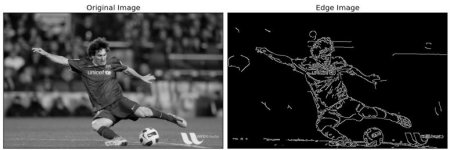

Ventajas:
- Produce líneas de un solo píxel de grosor, facilitando el análisis posterior.
- Tiene una excelente relación señal-ruido debido a que el paso inicial de desenfoque gaussiano elimina interferencias que otros filtros marcan como bordes.
- Puede detección de bordes débiles rescatando bordes tenues solo si están conectados a estructuras sólidas.
- Tiene una baja tasa de error ya que está diseñado para minimizar la detección de falsos positivos (ruido) y no perder bordes reales.
- Permite controlar la sensibilidad mediante los dos umbrales (alto y bajo).

Desventajas:
- Es más lento y complejo que otros operadores simples como Sobel.
- Si los valores de umbral no se ajustan manualmente para cada imagen, los resultados pueden variar drásticamente.
- El suavizado inicial puede borrar bordes muy finos o texturas importantes en imágenes de alta frecuencia.
- Está optimizado para líneas; a veces presenta problemas en uniones o esquinas muy cerradas.
- Si el cambio de intensidad es muy gradual (rampas de color), el filtro puede fallar al no encontrar un pico claro.

In [ ]:
# Filtro Canny
img = cv2.imread('imagen.jpg', 0)

edges = cv2.Canny(img, 100, 200)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')

plt.subplot(1,2,2)
plt.title("Canny")
plt.imshow(edges, cmap='gray')

plt.show()

Referencias:
1. https://grupo.us.es/gtocoma/pid/tema3-1.pdf
2. https://www.um.es/geograf/sigmur/teledet/tema06.pdf
3. https://www.researchgate.net/figure/Schematic-representation-of-mean-filtering-in-a-3X3-kernel-where-after-the-summation-of_fig1_348548607
4. https://www.researchgate.net/figure/Figura-3-Filtro-de-mediana-Observe-que-o-valor-do-pixel-central-sera-de-60-diferente_fig3_305823276
5. https://www.geeksforgeeks.org/python/log-transformation-of-an-image-using-python-and-opencv/
6. https://theailearner.com/tag/box-filter/
7. https://www.nv5geospatialsoftware.com/docs/LaplacianFilters.html
8. https://homepages.inf.ed.ac.uk/rbf/HIPR2/log.htm
9. https://homepages.inf.ed.ac.uk/rbf/HIPR2/sobel.htm
10. https://medium.com/lcc-unison/applying-sobel-filter-for-image-processing-using-parallel-computing-d1eae128b4e
11. https://medium.com/nattadet-c/image-filters-41c23f09c600
12. https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html

# DESCRIPTORES

In [ ]:
# Instalacion de dependencias para detectar granos de cafe en Google Colab.
# Consolidamos todas las dependencias de la seccion en una sola celda inicial.
!pip install roboflow torch torchvision scikit-learn scikit-image ipywidgets


In [ ]:
# Autenticacion en Roboflow leyendo la API key desde los Secrets de Colab.
# En Colab, ve al icono de la llave en el panel izquierdo y crea un secreto
# llamado ROBOFLOW_API_KEY con tu API key. Asegurate de habilitar el acceso
# del notebook al secreto.
ROBOFLOW_API_KEY_ENV = "ROBOFLOW_API_KEY"

api_key = userdata.get(ROBOFLOW_API_KEY_ENV)
rf = Roboflow(api_key=api_key)


In [ ]:
# Descarga del dataset desde Roboflow en formato COCO.
project = rf.workspace("billie-personal").project("coffee-bean-defects-900")
dataset = project.version(2).download("coco")

DATASET_PATH = dataset.location

In [ ]:
# Reorganiza las imagenes y anotaciones en una estructura sencilla dentro de
# /content/ (sistema de archivos efimero de Colab).
os.makedirs("/content/dataset/images", exist_ok=True)

# DATASET_PATH apunta a la carpeta descargada por Roboflow (p.ej. "./Coffee-Bean-Defects-900-2")
src = os.path.join(DATASET_PATH, "train")

for f in os.listdir(src):
    if f.endswith((".jpg", ".png")):
        shutil.copy(os.path.join(src, f), "/content/dataset/images/")

shutil.copy(
    os.path.join(src, "_annotations.coco.json"),
    "/content/dataset/_annotations.coco.json"
)


In [ ]:
# Dataset COCO personalizado para PyTorch.
TARGET_SIZE = 256

class COCODataset(Dataset):
    def __init__(self, root):
        self.root = root
        ann_path = os.path.join(root, "_annotations.coco.json")

        with open(ann_path) as f:
            self.coco = json.load(f)

        self.annotations = self.coco["annotations"]
        self.categories = self.coco["categories"]


        self.cat_to_idx = {cat["id"]: i for i, cat in enumerate(self.categories)}
        self.idx_to_name = {i: cat["name"] for i, cat in enumerate(self.categories)}

        self.img_to_anns = {}
        for ann in self.annotations:
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)

        # 2. FILTRO: Solo conservamos imagenes que SI tienen granos anotados
        self.images = [img for img in self.coco["images"] if img["id"] in self.img_to_anns]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.root, img_info["file_name"])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        flipped = False
        if np.random.rand() < 0.5:
            image = cv2.flip(image, 1)
            flipped = True

        h, w, _ = image.shape
        image = cv2.resize(image, (TARGET_SIZE, TARGET_SIZE))
        image = torch.tensor(image).permute(2,0,1).float() / 255.0

        # Al haber filtrado vacias en __init__, es seguro extraer [0]
        anns = self.img_to_anns[img_info["id"]]
        ann = anns[0]

        x_box, y_box, bw, bh = ann["bbox"]

        # Normalizacion [0, 1]
        x_norm = x_box / w
        y_norm = y_box / h
        bw_norm = bw / w
        bh_norm = bh / h

        if flipped:
            x_norm = 1.0 - x_norm - bw_norm

        boxes = [[x_norm, y_norm, x_norm + bw_norm, y_norm + bh_norm]]

        # 3. Aplicamos el MAPEO aqui para que PyTorch reciba un indice valido
        labels = [self.cat_to_idx[ann["category_id"]]]

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.long)
        }

        return image, target

In [ ]:
# Bloques residuales y detector ResNet personalizado.
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Segunda capa convolucional
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # "El Atajo" (Shortcut): Si cambiamos la resolucion o los canales, ajustamos la entrada original para poder sumarla
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x) # Guardamos la entrada procesada por el atajo

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # La magia de ResNet: sumamos la entrada original antes de la ultima activacion
        out += residual
        out = self.relu(out)

        return out

# 2. Reemplazamos el SimpleDetector por nuestro nuevo ResNetDetector
class ResNetDetector(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Capa inicial de entrada (Entra imagen 256x256 -> Sale mapa de 64x64)
        self.in_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.layer1 = ResidualBlock(32, 64, stride=2)   # Sale 32x32
        self.layer2 = ResidualBlock(64, 128, stride=2)  # Sale 16x16
        self.layer3 = ResidualBlock(128, 256, stride=2) # Sale 8x8

        # Head MEJORADA para Deteccion
        self.head = nn.Sequential(
            nn.Flatten(),
            # 256 canales * 8 de alto * 8 de ancho = 16384
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

        self.cls_head = nn.Linear(512, num_classes)
        self.box_head = nn.Linear(512, 4)

    def forward(self, x):
        x = self.in_conv(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.head(x)

        class_logits = self.cls_head(x)
        boxes = torch.sigmoid(self.box_head(x))

        return class_logits, boxes

In [ ]:
# Entrenador del detector basado en ResNet.
class DetectorTrainer:
    def __init__(self, dataset_path, batch_size=8, lr=1e-3, epochs=50, box_weight=20000.0):
        # 1. Hiperparametros y configuracion
        self.dataset_path = dataset_path
        self.batch_size = batch_size
        self.lr = lr
        self.epochs = epochs
        self.box_weight = box_weight
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # 2. Inicializar datos
        self._prepare_data()

        # 3. Inicializar modelo, optimizador, scheduler y funciones de perdida
        self.model = ResNetDetector(num_classes=len(self.dataset.categories)).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        # NUEVO: Programador de Learning Rate. Reduce a la mitad si el Val Loss no mejora en 3 epocas.
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', factor=0.5, patience=3)

        self.cls_loss_fn = nn.CrossEntropyLoss()
        self.box_loss_fn = nn.SmoothL1Loss()

    @staticmethod
    def collate_fn(batch):
        images, targets = zip(*batch)
        images = torch.stack(images)
        return images, targets

    @staticmethod
    def calculate_iou(boxA, boxB):

        xA = torch.max(boxA[:, 0], boxB[:, 0])
        yA = torch.max(boxA[:, 1], boxB[:, 1])
        xB = torch.min(boxA[:, 2], boxB[:, 2])
        yB = torch.min(boxA[:, 3], boxB[:, 3])

        interArea = torch.clamp(xB - xA, min=0) * torch.clamp(yB - yA, min=0)

        boxAArea = (boxA[:, 2] - boxA[:, 0]) * (boxA[:, 3] - boxA[:, 1])
        boxBArea = (boxB[:, 2] - boxB[:, 0]) * (boxB[:, 3] - boxB[:, 1])

        iou = interArea / (boxAArea + boxBArea - interArea + 1e-6)
        return iou.mean().item()

    def _prepare_data(self):
        """Carga el dataset, hace el split y crea los DataLoaders."""
        self.dataset = COCODataset(f"{self.dataset_path}/train")
        indices = list(range(len(self.dataset)))

        train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

        train_dataset = Subset(self.dataset, train_idx)
        val_dataset = Subset(self.dataset, val_idx)

        self.train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True, collate_fn=self.collate_fn)
        self.val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False, collate_fn=self.collate_fn)

    def evaluate(self):
        """Evalua el modelo en el conjunto de validacion."""
        self.model.eval()
        total_loss = 0
        total_iou = 0

        with torch.no_grad():
            for images, targets in self.val_loader:
                images = images.to(self.device)

                labels = torch.stack([t["labels"][0] for t in targets]).to(self.device)
                boxes = torch.stack([t["boxes"][0] for t in targets]).to(self.device)

                pred_cls, pred_box = self.model(images)

                loss_cls = self.cls_loss_fn(pred_cls, labels)
                loss_box = self.box_loss_fn(pred_box, boxes)

                total_loss += (loss_cls + (self.box_weight * loss_box)).item()
                total_iou += self.calculate_iou(pred_box, boxes) # Calculamos IoU del lote

        return total_loss / len(self.val_loader), total_iou / len(self.val_loader)

    def train(self):
        """Ejecuta el ciclo de entrenamiento."""
        print(f"Iniciando entrenamiento por {self.epochs} epocas en {self.device}...")

        for epoch in range(self.epochs):
            self.model.train()
            epoch_loss = 0
            epoch_iou = 0

            for images, targets in self.train_loader:
                images = images.to(self.device)

                labels = torch.stack([t["labels"][0] for t in targets]).to(self.device)
                boxes = torch.stack([t["boxes"][0] for t in targets]).to(self.device)

                pred_cls, pred_box = self.model(images)

                loss_cls = self.cls_loss_fn(pred_cls, labels)
                loss_box = self.box_loss_fn(pred_box, boxes)

                loss = loss_cls + (self.box_weight * loss_box)
                epoch_loss += loss.item()
                epoch_iou += self.calculate_iou(pred_box, boxes)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

            avg_train_loss = epoch_loss / len(self.train_loader)
            avg_train_iou = epoch_iou / len(self.train_loader)

            val_loss, val_iou = self.evaluate()

            self.scheduler.step(val_loss)
            current_lr = self.optimizer.param_groups[0]['lr']

            print(f"Epoch {epoch+1}/{self.epochs} | Train Loss: {avg_train_loss:.4f} (IoU: {avg_train_iou:.4f}) | Val Loss: {val_loss:.4f} (IoU: {val_iou:.4f}) | LR: {current_lr}")

        print("Entrenamiento completado!")

In [ ]:
trainer = DetectorTrainer(
    dataset_path=DATASET_PATH,
    batch_size=16,
    lr=1e-3,
    epochs=45,
    box_weight=200.0
)

trainer.train()

In [ ]:
trainer.evaluate()

In [ ]:
# Visualizacion de cajas predichas vs reales en el set de validacion.
trainer.model.eval()

images, targets = next(iter(trainer.val_loader))
images = images.to(trainer.device)

with torch.no_grad():
    pred_cls, pred_box = trainer.model(images)

fig, axes = plt.subplots(1, 6, figsize=(20, 5))

for i in range(6):
    ax = axes[i]

    img = images[i].cpu().permute(1, 2, 0).numpy()
    h, w, _ = img.shape
    ax.imshow(img)

    # --- CAJA REAL (Ground Truth) en VERDE ---
    true_box = targets[i]["boxes"][0].numpy()
    tx1, ty1 = true_box[0] * w, true_box[1] * h
    tbw, tbh = (true_box[2] - true_box[0]) * w, (true_box[3] - true_box[1]) * h

    rect_true = patches.Rectangle((tx1, ty1), tbw, tbh, linewidth=2, edgecolor='g', facecolor='none', label='Real')
    ax.add_patch(rect_true)

    # --- CAJA PREDICHA (Tu modelo) en ROJO ---
    p_box = pred_box[i].cpu().numpy()
    px1, py1 = p_box[0] * w, p_box[1] * h
    pbw, pbh = (p_box[2] - p_box[0]) * w, (p_box[3] - p_box[1]) * h

    rect_pred = patches.Rectangle((px1, py1), pbw, pbh, linewidth=2, edgecolor='r', facecolor='none', label='Prediccion')
    ax.add_patch(rect_pred)

    pred_label_idx = pred_cls[i].argmax(dim=0).item()
    true_label_idx = targets[i]["labels"][0].item()

    pred_name = trainer.dataset.idx_to_name[pred_label_idx]
    true_name = trainer.dataset.idx_to_name[true_label_idx]

    ax.set_title(f"Real: {true_name}\nPred: {pred_name}")
    ax.axis('off')

axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

## Guardar y Cargar el Modelo

Para evitar reentrenar el modelo en cada sesion guardamos los pesos junto con
los metadatos minimos (lista de categorias y mapa `idx -> nombre`) en un archivo
`.pt`. La funcion `load_model` reconstruye la arquitectura `ResNetDetector`
y carga los pesos en el dispositivo disponible.

In [ ]:
# Guarda el modelo entrenado para no tener que reentrenar.
def save_model(trainer, path="/content/coffee_detector.pt"):
    torch.save({
        "model_state_dict": trainer.model.state_dict(),
        "categories":       trainer.dataset.categories,
        "idx_to_name":      trainer.dataset.idx_to_name,
    }, path)
    print(f"Modelo guardado en {path}")


def load_model(path="/content/coffee_detector.pt", device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(path, map_location=device)
    num_classes = len(checkpoint["categories"])
    model = ResNetDetector(num_classes=num_classes)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    return model, checkpoint["idx_to_name"], device


save_model(trainer)


## Mejoras al Preprocesamiento

El `Dataset` original aplica solo *flip* horizontal y normaliza dividiendo entre
255. Para granos de cafe oscuros y de bajo contraste podemos hacer mucho mas:

- **CLAHE en el canal L de LAB**: ecualiza el contraste local sin reventar el
  color, ideal para superficies oscuras.
- **Normalizacion ImageNet** (`mean`, `std` clasicos): la red converge mas rapido
  cuando la entrada vive en el mismo rango estadistico con el que se entrenan
  las redes pre-entrenadas.
- **Augmentaciones**: rotacion `+/- 15`, jitter de brillo y contraste (alpha en
  `[0.8, 1.2]`, beta en `[-10, +10]`) y *flip* horizontal. Solo se activan
  cuando `augment=True`.
- **Anotacion principal por area**: cuando una imagen contiene varias bboxes nos
  quedamos con la de mayor area en lugar de tomar siempre la primera.

In [ ]:
class COCODatasetV2(Dataset):
    """Version mejorada del Dataset COCO con CLAHE, normalizacion ImageNet y
    augmentaciones (rotacion + jitter de brillo/contraste + flip horizontal).
    """

    MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(self, root, augment=False):
        self.root    = root
        self.augment = augment

        ann_path = os.path.join(root, "_annotations.coco.json")
        with open(ann_path) as f:
            self.coco = json.load(f)

        self.categories  = self.coco["categories"]
        self.cat_to_idx  = {cat["id"]: i for i, cat in enumerate(self.categories)}
        self.idx_to_name = {i: cat["name"] for i, cat in enumerate(self.categories)}

        self.img_to_anns = {}
        for ann in self.coco["annotations"]:
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)

        self.images = [
            img for img in self.coco["images"] if img["id"] in self.img_to_anns
        ]
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.images)

    def _apply_clahe(self, img_rgb):
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l = self.clahe.apply(l)
        return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.root, img_info["file_name"])
        image    = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        image    = self._apply_clahe(image)
        h, w, _  = image.shape

        # Anotacion con mayor area (mas robusto que tomar [0])
        anns = self.img_to_anns[img_info["id"]]
        ann  = max(anns, key=lambda a: a["bbox"][2] * a["bbox"][3])
        x_box, y_box, bw, bh = ann["bbox"]

        flipped = False
        if self.augment:
            # Flip horizontal (50%)
            if np.random.rand() < 0.5:
                image = cv2.flip(image, 1)
                flipped = True
            # Jitter de brillo y contraste
            alpha = np.random.uniform(0.8, 1.2)
            beta  = np.random.uniform(-10, 10)
            image = np.clip(image.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)
            # Rotacion pequena (+/- 15 grados)
            angle = np.random.uniform(-15, 15)
            M     = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
            image = cv2.warpAffine(image, M, (w, h))

        image      = cv2.resize(image, (TARGET_SIZE, TARGET_SIZE))
        img_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        img_tensor = (img_tensor - torch.tensor(self.MEAN).view(3, 1, 1)) \
                     / torch.tensor(self.STD).view(3, 1, 1)

        # bbox normalizada respecto al tamano original
        x_norm  = x_box / w
        y_norm  = y_box / h
        bw_norm = bw    / w
        bh_norm = bh    / h
        if flipped:
            x_norm = 1.0 - x_norm - bw_norm

        boxes  = [[x_norm, y_norm, x_norm + bw_norm, y_norm + bh_norm]]
        labels = [self.cat_to_idx[ann["category_id"]]]

        return img_tensor, {
            "boxes":  torch.tensor(boxes,  dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.long),
        }


## Definicion de Caracteristicas

Una *caracteristica* es un descriptor numerico que resume informacion util de la
imagen. En este bloque comparamos tres familias complementarias:

- **Embedding aprendido (512-D)**: salida de la cabeza compartida de la
  `ResNetDetector` (justo antes de las cabezas de clasificacion y bbox). Es la
  representacion que la red considera mas relevante para distinguir defectos.
- **HOG (Histogram of Oriented Gradients)**: caracteristica clasica que captura
  la *textura local* mediante histogramas de orientacion del gradiente. Util para
  formas y bordes.
- **Histograma de color por canal**: 32 bins en R, G y B. Captura el reparto
  cromatico global, util para distinguir granos verdes, dorados, negros, etc.

Comparar el embedding aprendido con HOG y color permite ver cuanta informacion
extra esta capturando la red respecto a descriptores hechos a mano.

In [ ]:
class FeatureExtractor:
    """Extrae embeddings de la red, HOG y un histograma de color por canal."""

    def __init__(self, model, device):
        self.model  = model
        self.device = device
        self.model.eval()

    def get_embedding(self, img_tensor):
        with torch.no_grad():
            x = img_tensor.unsqueeze(0).to(self.device)
            x = self.model.in_conv(x)
            x = self.model.layer1(x)
            x = self.model.layer2(x)
            x = self.model.layer3(x)
            embedding = self.model.head(x)
        return embedding.squeeze(0).cpu().numpy()

    def get_hog(self, img_tensor):
        img_np = img_tensor.permute(1, 2, 0).numpy()
        # Si vino normalizado con ImageNet stats podria estar fuera de [0,1];
        # lo recortamos para que el HOG opere sobre uint8 valido.
        img_np = np.clip(img_np, 0, 1)
        img_gray = cv2.cvtColor((img_np * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        features, _ = hog(
            img_gray,
            orientations=8,
            pixels_per_cell=(16, 16),
            cells_per_block=(2, 2),
            visualize=True,
        )
        return features

    def get_color_histogram(self, img_tensor):
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)
        histograms = []
        for ch in range(3):
            hist, _ = np.histogram(img_np[:, :, ch], bins=32, range=(0, 1))
            histograms.append(hist)
        return np.concatenate(histograms)

    def describe(self, img_tensor):
        emb     = self.get_embedding(img_tensor)
        hog_f   = self.get_hog(img_tensor)
        color_f = self.get_color_histogram(img_tensor)
        return {
            "embedding_dim":     emb.shape[0],
            "embedding_norm":    float(np.linalg.norm(emb)),
            "hog_dim":           hog_f.shape[0],
            "hog_energy":        float(np.sum(hog_f ** 2)),
            "color_hist_R_mean": float(color_f[:32].mean()),
            "color_hist_G_mean": float(color_f[32:64].mean()),
            "color_hist_B_mean": float(color_f[64:].mean()),
        }


# Demostracion sobre 4 imagenes del set de validacion
extractor = FeatureExtractor(trainer.model, trainer.device)
images_demo, targets_demo = next(iter(trainer.val_loader))

print(f"{'Imagen':<8} {'Emb Dim':<8} {'Emb Norm':<10} {'HOG Dim':<8} "
      f"{'HOG Energy':<12} {'R hist':<10} {'G hist':<10} {'B hist':<10}")
print("-" * 80)
for i in range(4):
    desc = extractor.describe(images_demo[i])
    print(
        f"{i:<8} {desc['embedding_dim']:<8} {desc['embedding_norm']:<10.4f} "
        f"{desc['hog_dim']:<8} {desc['hog_energy']:<12.4f} "
        f"{desc['color_hist_R_mean']:<10.4f} {desc['color_hist_G_mean']:<10.4f} "
        f"{desc['color_hist_B_mean']:<10.4f}"
    )


## Metricas Completas de Evaluacion

Mas alla del IoU promedio que ya devolvia el `trainer`, una evaluacion seria
necesita varias metricas:

- **IoU promedio**: solapamiento medio entre bbox predicha y real.
- **Precision por clase**: de las predicciones de cada clase, cuantas eran
  correctas (`TP / (TP + FP)`).
- **Recall por clase**: de los ejemplos reales de cada clase, cuantos detectamos
  (`TP / (TP + FN)`).
- **F1-score**: media armonica entre precision y recall, util cuando las clases
  estan desbalanceadas.
- **mAP@0.5 simplificado**: porcentaje de muestras con clase correcta *y*
  IoU >= 0.5 con la caja real. Es la metrica estandar de deteccion.
- **Matriz de confusion**: muestra graficamente cuales clases se confunden entre
  si, lo que ayuda a decidir donde reforzar el dataset.

In [ ]:
def compute_metrics(trainer):
    """Calcula IoU, precision/recall/F1 por clase, mAP@0.5 y matriz de confusion
    sobre el set de validacion completo."""
    model       = trainer.model
    model.eval()
    device      = trainer.device
    idx_to_name = trainer.dataset.idx_to_name
    num_classes = len(trainer.dataset.categories)

    all_true_cls = []
    all_pred_cls = []
    all_iou      = []

    with torch.no_grad():
        for images, targets in trainer.val_loader:
            images = images.to(device)
            labels = torch.stack([t["labels"][0] for t in targets]).to(device)
            boxes  = torch.stack([t["boxes"][0]  for t in targets]).to(device)

            pred_cls, pred_box = model(images)
            pred_labels = pred_cls.argmax(dim=1)

            for j in range(len(labels)):
                bA  = pred_box[j].unsqueeze(0)
                bB  = boxes[j].unsqueeze(0)
                iou = DetectorTrainer.calculate_iou(bA, bB)
                all_iou.append(iou)
                all_true_cls.append(labels[j].item())
                all_pred_cls.append(pred_labels[j].item())

    all_true_cls = np.array(all_true_cls)
    all_pred_cls = np.array(all_pred_cls)
    all_iou      = np.array(all_iou)

    mean_iou = all_iou.mean()

    # Precision, Recall, F1 por clase
    precision, recall, f1, support = precision_recall_fscore_support(
        all_true_cls,
        all_pred_cls,
        labels=list(range(num_classes)),
        zero_division=0,
    )

    # mAP@0.5 simplificado: clase correcta AND IoU >= 0.5
    correct = (all_true_cls == all_pred_cls) & (all_iou >= 0.5)

    print(f"\n{'==='*20}")
    print(f"  METRICAS COMPLETAS - SET DE VALIDACION")
    print(f"{'==='*20}")
    print(f"  IoU promedio    : {mean_iou:.4f}")
    print(f"  mAP@0.5         : {correct.mean():.4f}  "
          f"({correct.sum()}/{len(correct)} correctas)\n")
    print(f"  {'Clase':<30} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Soporte':>10}")
    print(f"  {'-' * 70}")
    for i in range(num_classes):
        name = idx_to_name.get(i, str(i))
        print(f"  {name:<30} {precision[i]:>10.4f} {recall[i]:>10.4f} "
              f"{f1[i]:>10.4f} {int(support[i]):>10}")
    print(f"{'==='*20}\n")

    # Matriz de confusion
    labels_names = [idx_to_name.get(i, str(i)) for i in range(num_classes)]
    cm = confusion_matrix(
        all_true_cls, all_pred_cls, labels=list(range(num_classes))
    )
    fig, ax = plt.subplots(figsize=(max(8, num_classes), max(6, num_classes - 2)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
    ax.set_title("Matriz de Confusion - Clasificacion de defectos")
    plt.tight_layout()
    plt.show()

    return {
        "mean_iou":  mean_iou,
        "mAP_0.5":   correct.mean(),
        "precision": precision,
        "recall":    recall,
        "f1":        f1,
    }


metrics = compute_metrics(trainer)


## Interfaz Grafica Interactiva

Para probar el modelo en imagenes nuevas sin recurrir a servidores externos
(Gradio, Streamlit, etc.) usamos `ipywidgets` directamente dentro del notebook.
La interfaz permite:

1. **Subir una imagen** mediante `FileUpload`.
2. **Ejecutar la inferencia** con el modelo entrenado al pulsar el boton.
3. **Visualizar el resultado**: imagen original + imagen con la bbox y la
   etiqueta sobrepuesta.
4. **Mostrar la confianza** (softmax) de la clase ganadora y un grafico de
   barras horizontales con la probabilidad de cada clase.

In [ ]:
def preprocess_for_inference(img_rgb, target_size=256):
    """Preprocesa una imagen RGB numpy para pasarla al modelo."""
    img    = cv2.resize(img_rgb, (target_size, target_size))
    tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
    return tensor.unsqueeze(0)


def run_inference_colab(model, idx_to_name, device):
    """Version alternativa para Colab: usa google.colab.files para cargar la imagen."""
    print("Selecciona una imagen de tu equipo:")
    uploaded = colab_files.upload()
    if not uploaded:
        print("No se seleccionó ningún archivo.")
        return
    filename = list(uploaded.keys())[0]
    img_bytes = uploaded[filename]
    pil_img = PILImage.open(io.BytesIO(img_bytes)).convert('RGB')
    img_rgb = np.array(pil_img)

    tensor = preprocess_for_inference(img_rgb).to(device)
    model.eval()
    with torch.no_grad():
        pred_cls, pred_box = model(tensor)

    probs      = torch.softmax(pred_cls[0], dim=0)
    class_idx  = probs.argmax().item()
    confidence = probs[class_idx].item()
    class_name = idx_to_name.get(class_idx, str(class_idx))
    box        = pred_box[0].cpu().numpy()

    h, w, _ = img_rgb.shape
    x1 = int(box[0] * w); y1 = int(box[1] * h)
    x2 = int(box[2] * w); y2 = int(box[3] * h)
    vis = img_rgb.copy()
    cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 80, 80), 3)
    label_txt = f"{class_name} ({confidence:.1%})"
    cv2.putText(vis, label_txt, (x1, max(y1-10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 80, 80), 2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(img_rgb); axes[0].set_title("Imagen original"); axes[0].axis('off')
    axes[1].imshow(vis);     axes[1].set_title(f"Predicción: {class_name}"); axes[1].axis('off')

    fig2, ax2 = plt.subplots(figsize=(8, 3))
    names  = [idx_to_name.get(i, str(i)) for i in range(len(probs))]
    colors = ['#e74c3c' if i == class_idx else '#3498db' for i in range(len(probs))]
    ax2.barh(names, probs.cpu().numpy(), color=colors)
    ax2.set_xlabel("Probabilidad"); ax2.set_title("Confianza por clase"); ax2.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

# Ejecutar interfaz
run_inference_colab(trainer.model, trainer.dataset.idx_to_name, trainer.device)
